# **1DCNN модель, для задачм предсказания ECM параметров**.

## Загрузка данных

Библиотеки

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm
import os
import random

Распаковка данных

In [2]:
!python -m zipfile -e /content/param_ecm-new_data_param.zip /content/

### Загрузка датасетов.

In [3]:
target_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_main.csv'

feature_path = r'/content/param_ecm-new_data_param/plsDS_soc455055_fr2_1RC_R0free_pls_tables'

In [4]:
y_data = pd.read_csv(target_path)
y_data.head(3)

,I,R0,R1,R2,Udrop,Ufin,Uinit,cellcap,dSoC,dltQ,name,nominal_soc,tau1,tau2,tau_pls,table_file
0,-1.699624,0.035922,0.021680,0.002503,0.0576,3.6642,3.6656,3.36,-0.001265,-15.296620,soc45_05Cdch_9sec,0.45,49.006981,100,9,soc45_05Cdch_9sec.csv
1,-1.699615,0.038267,0.026703,0.004275,0.0596,3.6627,3.6653,3.36,-0.002529,-30.593065,soc45_05Cdch_18sec,0.45,71.978738,100,18,soc45_05Cdch_18sec.csv
2,-1.699670,0.039573,0.029765,0.006881,0.0597,3.6611,3.6656,3.36,-0.005059,-61.188125,soc45_05Cdch_36sec,0.45,98.442333,100,36,soc45_05Cdch_36sec.csv


In [5]:
X_data_dict = {}

for filename in os.listdir(feature_path):
  if filename.endswith('.csv'):
    full_path = os.path.join(feature_path, filename)

    X_data_dict[filename] = pd.read_csv(full_path)[['Time', 'I', 'E']]

filenames_list = list(X_data_dict.keys())

print(f"Всего файлов загружено: {len(filenames_list)}")
print(f"Первый файл: {filenames_list[0]}")

Всего файлов загружено: 72
Первый файл: soc45_1Cchr_9sec.csv


In [6]:
first_filename = filenames_list[0]
first_dataframe = X_data_dict[first_filename]

first_dataframe.head(3)

,Time,I,E
0,0.0,3.3983,3.7847
1,0.1,3.3983,3.7847
2,0.2,3.3984,3.7859


### Преобразуем данные, оставим, только что нужно.

In [7]:
y_data_valid = y_data.copy()

y_data_valid = y_data_valid[['R0', 'R1', 'R2', 'tau1', 'tau2', 'table_file']]
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2,table_file
0,0.035922,0.021680,0.002503,49.006981,100,soc45_05Cdch_9sec.csv
1,0.038267,0.026703,0.004275,71.978738,100,soc45_05Cdch_18sec.csv
2,0.039573,0.029765,0.006881,98.442333,100,soc45_05Cdch_36sec.csv


In [8]:
y_data_valid = y_data_valid.set_index('table_file')
y_data_valid.head(3)

,R0,R1,R2,tau1,tau2
table_file,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,49.006981,100
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,71.978738,100
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,98.442333,100


Проверю доступность строк.

In [9]:
y_data_valid.loc['soc45_05Cdch_9sec.csv']

,soc45_05Cdch_9sec.csv
R0,0.035922
R1,0.021680
R2,0.002503
tau1,49.006981
tau2,100.000000


Преобразуем tau в C по формуле C = tau / R

In [11]:
y_data_ECM = y_data_valid.copy()
y_data_ECM['C1'] = y_data_ECM['tau1'] / y_data_ECM['R1']
y_data_ECM['C2'] = y_data_ECM['tau2'] / y_data_ECM['R2']
y_data_ECM = y_data_ECM.drop(columns = ['tau1', 'tau2'])
y_data_ECM

,R0,R1,R2,C1,C2
table_file,,,,,
soc45_05Cdch_9sec.csv,0.035922,0.021680,0.002503,2260.448803,39953.664553
soc45_05Cdch_18sec.csv,0.038267,0.026703,0.004275,2695.552979,23393.126693
soc45_05Cdch_36sec.csv,0.039573,0.029765,0.006881,3307.338185,14533.132864
soc45_05Cdch_72sec.csv,0.040419,0.026845,0.009549,4039.711416,10472.793336
soc45_05Cdch_144sec.csv,0.041387,0.024470,0.012494,5041.127631,8003.795124
...,...,...,...,...,...
soc55_1Cchr_36sec.csv,0.037162,0.015144,0.004966,2894.353334,20136.191961
soc55_1Cchr_72sec.csv,0.037716,0.014151,0.006390,3256.514024,15650.545530
soc55_2Cchr_9sec.csv,0.035879,0.016251,0.002251,2243.239787,44432.795075


### Данные и их статистики.

Фичи

In [12]:
X_data_dict['soc45_05Cchr_144sec.csv'].describe()

,Time,I,E
count,5163.000000,5163.000000,5163.000000
mean,755.717606,0.474423,3.691385
std,1540.981196,0.762543,0.032478
min,0.000000,0.000000,3.667200
25%,129.050000,0.000000,3.669300
50%,258.000000,0.000000,3.671600
75%,387.050000,1.699800,3.726700
max,7644.000000,1.699900,3.756300


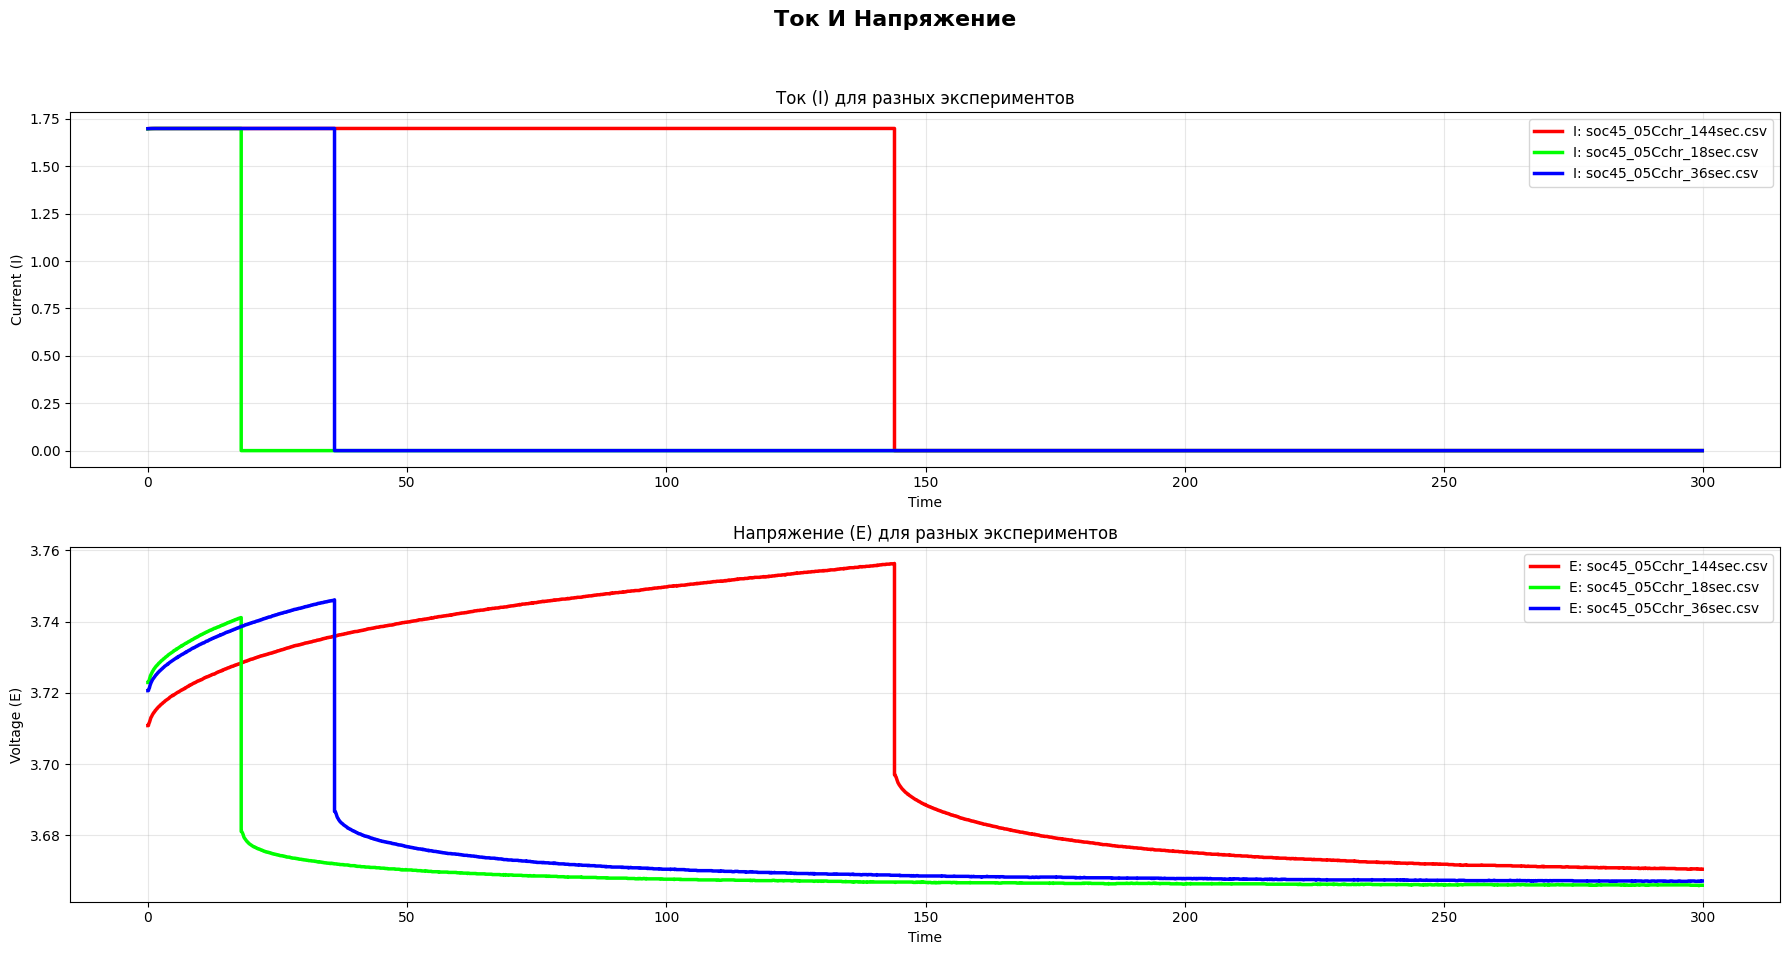

In [13]:
filenames_list = sorted([f for f in X_data_dict.keys() if f.endswith('.csv')])
files_to_plot = filenames_list[:3]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(18, 10))
axes = axes.flatten()

colors = ['#FF0000', '#00FF00', '#0000FF']

for i, filename in enumerate(files_to_plot):
    df = X_data_dict[filename]
    color = colors[i % len(colors)]

    df_trimmed = df.iloc[:3000]

    ax_I = axes[0]
    ax_I.plot(df_trimmed['Time'], df_trimmed['I'], color=color, linewidth=2.5, alpha=1.0, label=f'I: {filename}')
    ax_I.set_title('Ток (I) для разных экспериментов')
    ax_I.set_xlabel('Time')
    ax_I.set_ylabel('Current (I)')
    ax_I.grid(True, alpha=0.3)
    ax_I.legend(loc='upper right')

    ax_E = axes[1]
    ax_E.plot(df_trimmed['Time'], df_trimmed['E'], color=color, linewidth=2.5, alpha=1.0, label=f'E: {filename}', linestyle='-')
    ax_E.set_title('Напряжение (E) для разных экспериментов')
    ax_E.set_xlabel('Time')
    ax_E.set_ylabel('Voltage (E)')
    ax_E.grid(True, alpha=0.3)
    ax_E.legend(loc='upper right')

plt.suptitle('Ток И Напряжение', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Целевые переменные.

In [15]:
y_data_ECM.describe()

,R0,R1,R2,C1,C2
count,72.000000,72.000000,72.000000,72.000000,72.000000
mean,0.037798,0.016566,0.004256,2938.142860,30444.090833
std,0.001375,0.004256,0.002338,724.953135,14392.921918
min,0.035610,0.011923,0.001788,2072.970226,8003.795124
25%,0.036876,0.013499,0.002353,2381.254793,16902.833689
50%,0.037680,0.015058,0.003422,2703.250993,29259.469064
75%,0.038596,0.018286,0.005916,3262.904020,42513.810600
max,0.041387,0.029765,0.012494,5051.794002,55921.525371


## Разобьем данные на train и validation

In [17]:
random.seed(42)

model_names = list(X_data_dict.keys())
random.shuffle(model_names)

split_idx = int(0.8 * len(model_names))

In [18]:
train_keys = model_names[:split_idx]
val_keys = model_names[split_idx:]

train_data = {key: X_data_dict[key] for key in train_keys}
val_data = {key: X_data_dict[key] for key in val_keys}

print(f"Всего моделей: {len(model_names)}")
print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")

Всего моделей: 72
Train: 57
Val: 15


In [19]:
print(train_keys)

['soc55_2Cchr_9sec.csv', 'soc50_1Cchr_9sec.csv', 'soc50_2Cdch_9sec.csv', 'soc55_1Cchr_9sec.csv', 'soc50_1Cchr_72sec.csv', 'soc55_2Cchr_18sec.csv', 'soc50_05Cchr_36sec.csv', 'soc45_05Cchr_18sec.csv', 'soc55_3Cchr_9sec.csv', 'soc45_1Cdch_18sec.csv', 'soc50_2Cchr_9sec.csv', 'soc55_05Cchr_36sec.csv', 'soc55_1Cchr_72sec.csv', 'soc50_05Cdch_9sec.csv', 'soc50_05Cdch_72sec.csv', 'soc45_1Cchr_18sec.csv', 'soc45_2Cchr_18sec.csv', 'soc55_05Cdch_144sec.csv', 'soc45_05Cchr_9sec.csv', 'soc55_1Cdch_18sec.csv', 'soc45_2Cchr_9sec.csv', 'soc50_2Cdch_18sec.csv', 'soc55_05Cdch_72sec.csv', 'soc55_1Cchr_36sec.csv', 'soc50_05Cdch_18sec.csv', 'soc50_1Cdch_36sec.csv', 'soc50_1Cdch_9sec.csv', 'soc45_1Cchr_72sec.csv', 'soc50_1Cdch_72sec.csv', 'soc45_05Cdch_36sec.csv', 'soc55_05Cdch_36sec.csv', 'soc45_1Cchr_36sec.csv', 'soc55_05Cdch_18sec.csv', 'soc45_1Cdch_9sec.csv', 'soc50_1Cchr_18sec.csv', 'soc55_1Cdch_9sec.csv', 'soc55_1Cdch_36sec.csv', 'soc50_05Cdch_36sec.csv', 'soc50_2Cchr_18sec.csv', 'soc55_2Cdch_9sec.csv'

In [21]:
y_train, y_val = y_data_ECM.loc[train_keys], y_data_ECM.loc[val_keys]
y_train.shape, y_val.shape

((57, 5), (15, 5))

## Нормировка

In [24]:
all_train_x = np.concatenate([
    np.stack([
        train_data[key]["I"].to_numpy(),
        train_data[key]["E"].to_numpy()
    ], axis=1)
    for key in train_keys
], axis=0).astype(np.float64)

x_mean = all_train_x.mean(axis=0)
x_std = all_train_x.std(axis=0) + 1e-8

print("x_mean:", x_mean)
print("x_std:", x_std)

x_mean: [0.01743686 3.70813749]
x_std: [0.87715572 0.05154636]


In [28]:
all_train_y = np.stack([
    y_train.loc[key]
    for key in train_keys
], axis=0).astype(np.float64)

y_mean = all_train_y.mean(axis=0)
y_std = all_train_y.std(axis=0) + 1e-8

print("y_mean:", y_mean)
print("y_std:", y_std)

y_mean: [3.76968089e-02 1.62857606e-02 3.98817820e-03 2.87783916e+03
 3.19778754e+04]
y_std: [1.37582049e-03 3.98476152e-03 2.06681047e-03 6.80099475e+02
 1.44725895e+04]


## Dataset

In [106]:
class ECMDataset(Dataset):
    def __init__(self, data_dict, target_dict, keys, x_mean, x_std, y_mean, y_std):
        self.keys = keys

        self.data_arrays = {}
        for key in keys:
            df = data_dict[key]
            self.data_arrays[key] = np.stack([
                df["I"].to_numpy(),
                df["E"].to_numpy()
            ], axis=1).astype(np.float32)

        self.targets = target_dict.loc[keys].values.astype(np.float32)

        self.x_mean = x_mean.astype(np.float32)
        self.x_std = x_std.astype(np.float32)
        self.y_mean = y_mean.astype(np.float32)
        self.y_std = y_std.astype(np.float32)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]

        x = self.data_arrays[key]
        y = self.targets[idx]

        x = (x - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std

        return torch.tensor(x), torch.tensor(y)

In [49]:
def collate_fn(batch):
    xs, ys = zip(*batch)

    lengths = torch.tensor([x.size(0) for x in xs], dtype=torch.long)
    x_padded = pad_sequence(xs, batch_first=True)
    y = torch.stack(ys)

    mask = torch.arange(x_padded.size(1))[None, :] < lengths[:, None]
    mask = mask.to(torch.bool)

    return x_padded, y, mask

## Подготовка данных: Dataset -> Dataloader

In [50]:
train_dataset = ECMDataset(
    data_dict=train_data,
    target_dict=y_train,
    keys=train_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

val_dataset = ECMDataset(
    data_dict=val_data,
    target_dict=y_val,
    keys=val_keys,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

In [51]:
train_dataset[0]

(tensor([[ 7.7283,  5.3265],
         [ 7.7283,  5.3265],
         [ 7.7287,  5.3731],
         ...,
         [-0.0199,  1.0061],
         [-0.0199,  1.0061],
         [-0.0199,  1.0061]]),
 tensor([-1.3211, -0.0086, -0.8407, -0.9331,  0.8606]))

In [52]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [53]:
x_batch, y_batch, mask_batch = next(iter(train_loader))

print("x_batch.shape =", x_batch.shape)
print("y_batch.shape =", y_batch.shape)
print("mask_batch.shape =", mask_batch.shape)

x_batch.shape = torch.Size([16, 7173, 2])
y_batch.shape = torch.Size([16, 5])
mask_batch.shape = torch.Size([16, 7173])


In [54]:
x_batch[0]

tensor([[3.8545, 2.2070],
        [3.8545, 2.2070],
        [3.8546, 2.2303],
        ...,
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000]])

In [55]:
y_batch[0]

tensor([-0.9551, -0.2065, -0.9285, -0.9100,  1.1297])

## Модель на основе 1D-CNN

In [114]:
class D1_CNN(nn.Module):
  def __init__(self, input_size = 2, out_size = 5, hiden_size = 16, dropout = 0.1):
    super().__init__()

    self.conv_d1cnn_1 = nn.Conv1d(in_channels = input_size, out_channels = hiden_size * 2, kernel_size = 3, padding = 1)
    self.conv_d1cnn_2 = nn.Conv1d(in_channels = hiden_size * 2, out_channels = hiden_size * 4, kernel_size = 3, padding = 1)
    self.conv_d1cnn_3 = nn.Conv1d(in_channels = hiden_size * 4, out_channels = hiden_size * 8, kernel_size = 3, padding = 1)

    self.bn1 = nn.BatchNorm1d(hiden_size * 2)
    self.bn2 = nn.BatchNorm1d(hiden_size * 4)
    self.bn3 = nn.BatchNorm1d(hiden_size * 8)
    self.bn4 = nn.BatchNorm1d(hiden_size * 8)
    self.bn5 = nn.BatchNorm1d(hiden_size * 8)

    self.dropout = nn.Dropout(dropout)
    self.relu = nn.ReLU()

    self.fc = nn.Linear(hiden_size * 8, out_size)

  def forward(self, x, mask = None):
    x = x.permute(0, 2, 1)

    x = self.conv_d1cnn_1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.conv_d1cnn_2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.conv_d1cnn_3(x)
    x = self.bn3(x)
    x = self.relu(x)
    x = self.dropout(x)

    if mask is not None:
      mask = mask.unsqueeze(1)
      x = x * mask
      x = x.sum(dim = 2) / mask.sum(dim = 2).clamp(min = 1)
    else:
      x = x.mean(dim = 2)

    x = self.fc(x)

    return x

## Обучение

In [118]:
model = D1_CNN(input_size=2, out_size=5, hiden_size=8, dropout=0.4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [119]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [120]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for x_batch, y_batch, mask_batch in train_pbar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()

        output = model(x_batch, mask_batch)

        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_pbar.set_postfix({"train_loss": f"{train_loss / len(train_loader):.4f}"})

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Validation")

        for x_batch, y_batch, mask_batch in val_pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            output = model(x_batch, mask_batch)

            loss = criterion(output, y_batch)
            val_loss += loss.item()

            val_pbar.set_postfix({"val_loss": f"{val_loss / len(val_loader):.4f}"})

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

torch.save(model.state_dict(), "d1_cnn_model.pth")

Epoch 1/50:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/4 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/4 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

## Предсказания.

In [121]:
def calculate_mape(y_true, y_pred):
    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    mape = mean_absolute_percentage_error(y_true, y_pred, multioutput = 'raw_values')
    return mape

In [122]:
def test_model(model, test_loader, device):
    model.eval()

    all_y_true = []
    all_y_pred = []

    test_loss = 0.0

    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc="Testing")

        for batch in test_pbar:
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                output = model(x_batch)

            loss = criterion(output, y_batch)
            test_loss += loss.item()

            all_y_true.append(y_batch.cpu())
            all_y_pred.append(output.cpu())

            test_pbar.set_postfix({"test_loss": f"{loss.item():.4f}"})

    test_loss /= len(test_loader)

    y_true = torch.cat(all_y_true, dim=0) * y_std + y_mean
    y_pred = torch.cat(all_y_pred, dim=0) * y_std + y_mean

    mape = calculate_mape(y_true, y_pred)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"MAPE: {100*mape}%")

    return y_true, y_pred, mape

In [123]:
def predict(model, data_loader, device):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            if len(batch) == 3:
                x_batch, y_batch, mask_batch = batch
                x_batch = x_batch.to(device)
                mask_batch = mask_batch.to(device)

                output = model(x_batch, mask_batch)
            else:
                x_batch, y_batch = batch
                x_batch = x_batch.to(device)

                output = model(x_batch)

            all_predictions.append(output.cpu())
            all_targets.append(y_batch.cpu())

    predictions = torch.cat(all_predictions, dim=0).numpy()
    targets = torch.cat(all_targets, dim=0).numpy()

    return predictions, targets

In [124]:
model = D1_CNN(input_size=2, out_size=5, hiden_size=16, dropout=0.1).to(device)
# model.load_state_dict(torch.load("d1_cnn_model.pth"))

y_true, y_pred, mape = test_model(model, val_loader, device)

predictions, targets = predict(model, val_loader, device)

print(f"Predictions shape: {predictions.shape}")
print(f"Targets shape: {targets.shape}")

Testing:   0%|          | 0/1 [00:00<?, ?it/s]

Test Loss: 1.5306
MAPE: [ 2.82170836 21.78024599 40.89086128 19.92441477 81.76653987]%


/tmp/ipykernel_360/3887333420.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.cat(all_y_true, dim=0) * y_std + y_mean
/tmp/ipykernel_360/3887333420.py:38: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = torch.cat(all_y_pred, dim=0) * y_std + y_mean


Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

Predictions shape: (15, 5)
Targets shape: (15, 5)


In [125]:
y_true[:3]

tensor([[3.8161e-02, 1.3445e-02, 2.9539e-03, 2.6519e+03, 3.3854e+04],
        [3.8570e-02, 1.4135e-02, 7.9984e-03, 3.9545e+03, 1.2502e+04],
        [3.8178e-02, 2.6545e-02, 2.8303e-03, 2.0730e+03, 3.5332e+04]],
       dtype=torch.float64)

In [126]:
y_pred[:3]

tensor([[3.7592e-02, 1.6360e-02, 3.9934e-03, 2.7997e+03, 3.2425e+04],
        [3.7666e-02, 1.6205e-02, 4.1331e-03, 2.8044e+03, 3.2701e+04],
        [3.7697e-02, 1.6113e-02, 4.1062e-03, 2.8108e+03, 3.2928e+04]],
       dtype=torch.float64)